# LUCY -- Notebook 4: Fight Detection (Real Life Violence Situations)
## FightLSTM: Detección de peleas con YOLOv8-pose + BiLSTM

**Dataset:** Real Life Violence Situations (RLVS) — 2000 clips reales de YouTube y cámaras de vigilancia
**Paper:** Soliman et al., *"Violence Recognition from Videos using Deep Learning Techniques"*, ICICIS'19, Cairo 2019

**Pipeline completo:**
```
2000 videos (Violence / NonViolence)
  → YOLOv8n-pose (CUDA)  →  17 keypoints COCO por persona, por frame
  → Normalización relativa al cuerpo  (independiente de posición y escala)
  → Secuencia de 30 frames  →  FightLSTM (BiLSTM)
  → FIGHT / NO_FIGHT  +  probabilidad de confianza
```

**Por qué keypoints y no píxeles:**
El modelo aprende de la geometría del movimiento corporal, no de colores ni texturas.
Esto lo hace robusto a cambios de iluminación, ropa y cámara.
Un peatón corriendo parece diferente a una pelea aunque los píxeles sean similares.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os, glob, random, warnings, time
from pathlib import Path
from collections import Counter
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
warnings.filterwarnings('ignore')

try:
    from sklearn.metrics import (confusion_matrix, classification_report,
                                  roc_curve, auc)
    import seaborn as sns
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print('[WARN] pip install scikit-learn seaborn')

from ultralytics import YOLO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs('models', exist_ok=True)
os.makedirs('output', exist_ok=True)

print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'sklearn: {HAS_SKLEARN}')

Device : cuda
GPU    : NVIDIA GeForce RTX 5050 Laptop GPU
sklearn: True


In [2]:
# ── Rutas ──────────────────────────────────────────────────────────────────────
DATASET_DIR  = 'datasets/Real Life Violence Dataset'
CACHE_PATH   = 'datasets/fight_keypoints.npz'
SAVE_PATH    = 'models/fight_detector.pth'

# ── Extracción de keypoints ────────────────────────────────────────────────────
N_FRAMES     = 30    # frames muestreados por video (distribuidos uniformemente)
N_PEOPLE     = 2     # máximo de personas por frame (las 2 de mayor confianza)
N_KP         = 17    # keypoints COCO por persona — estándar de YOLOv8-pose
FEATURES     = N_PEOPLE * N_KP * 2   # 68 features por frame

# ── Arquitectura ───────────────────────────────────────────────────────────────
HIDDEN_SIZE  = 256   # neuronas por dirección en el BiLSTM
NUM_LAYERS   = 2     # capas apiladas del LSTM (aprendizaje jerárquico)
DROPOUT      = 0.4   # regularización para evitar overfitting

# ── Entrenamiento ──────────────────────────────────────────────────────────────
EPOCHS       = 40
BATCH_SIZE   = 32
LR           = 1e-3
WEIGHT_DECAY = 1e-4

# ── Clases ─────────────────────────────────────────────────────────────────────
CLASSES      = ['NonViolence', 'Violence']
N_CLASSES    = 2

print('Constantes OK')
print(f'  Dataset  : {DATASET_DIR}')
print(f'  Features : {FEATURES} por frame  ({N_PEOPLE} personas x {N_KP} kp x 2 coords)')
print(f'  Secuencia: {N_FRAMES} frames por video')
print(f'  Input BiLSTM: ({N_FRAMES}, {FEATURES})')

Constantes OK
  Dataset  : datasets/Real Life Violence Dataset
  Features : 68 por frame  (2 personas x 17 kp x 2 coords)
  Secuencia: 30 frames por video
  Input BiLSTM: (30, 68)


## 1. Extracción de Keypoints con YOLOv8-pose

**YOLOv8n-pose** detecta personas en cada frame y estima 17 puntos del cuerpo (esqueleto COCO):
nariz, ojos, orejas, hombros, codos, muñecas, caderas, rodillas, tobillos.

**Muestreo uniforme de 30 frames:**
En lugar de tomar los primeros 30 frames (que podrían ser solo la intro del video), usamos
`np.linspace(0, total-1, 30)` para cubrir el video completo de inicio a fin.

**Normalización relativa al cuerpo:**
- Centro de referencia: punto medio entre cadera izquierda (kp 11) y cadera derecha (kp 12)
- Escala: distancia entre centro de caderas y centro de hombros (= altura del torso)
- Resultado: coordenadas que NO dependen de dónde está la persona en el frame ni su distancia a la cámara

**Cache en disco:**
Procesar 2000 videos toma ~15 minutos. Los keypoints se guardan en `fight_keypoints.npz`
para que todas las ejecuciones siguientes sean instantáneas.


In [3]:
_pose_model = None

def _get_pose_model():
    """Carga YOLOv8n-pose una sola vez y lo reutiliza en todas las llamadas."""
    global _pose_model
    if _pose_model is None:
        # yolov8n-pose.pt se descarga automaticamente (~6 MB) si no existe localmente
        _pose_model = YOLO('yolov8n-pose.pt')
    return _pose_model


def _normalize_keypoints(kp_pixels, img_w, img_h):
    """
    Convierte keypoints de píxeles a coordenadas relativas al cuerpo.

    Parámetros
    ----------
    kp_pixels : np.ndarray (17, 2)  coordenadas en píxeles
    img_w, img_h : dimensiones del frame

    Retorna
    -------
    np.ndarray (34,)  keypoints normalizados y aplanados
    """
    kp = kp_pixels.astype(np.float32).copy()

    # Paso 1: llevar a rango [0, 1] según dimensiones del frame
    kp[:, 0] /= (img_w + 1e-6)
    kp[:, 1] /= (img_h + 1e-6)

    # Índices COCO: 5=hombro_izq, 6=hombro_der, 11=cadera_izq, 12=cadera_der
    hip_center      = (kp[11] + kp[12]) / 2.0
    shoulder_center = (kp[5]  + kp[6])  / 2.0
    torso_height    = float(np.linalg.norm(shoulder_center - hip_center)) + 1e-6

    # Si caderas/hombros no son visibles (coords ~ 0), usar centroide de puntos visibles
    if torso_height < 0.02:
        visible = kp[(kp[:, 0] > 0.01) | (kp[:, 1] > 0.01)]
        if len(visible) >= 2:
            hip_center   = visible.mean(axis=0)
            torso_height = 0.15  # escala fija de fallback
        else:
            return kp.flatten()  # sin datos suficientes, devolver sin centrar

    # Paso 2: centrar en caderas y escalar por altura del torso
    kp_norm = (kp - hip_center) / torso_height
    return kp_norm.flatten()


def extract_keypoints(video_path):
    """
    Extrae keypoints de N_FRAMES frames de un video.

    Retorna
    -------
    np.ndarray (N_FRAMES, FEATURES=68)
    Cada fila: [persona_1_kp(34), persona_2_kp(34)]
    Slots sin detección: ceros.
    """
    model = _get_pose_model()
    cap   = cv2.VideoCapture(video_path)

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return np.zeros((N_FRAMES, FEATURES), dtype=np.float32)

    # Índices distribuidos uniformemente de inicio a fin del video
    indices = np.linspace(0, total - 1, N_FRAMES, dtype=int)

    out   = np.zeros((N_FRAMES, FEATURES), dtype=np.float32)
    img_h = img_w = 1

    for i, frame_idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        ret, frame = cap.read()
        if not ret or frame is None:
            continue

        img_h, img_w = frame.shape[:2]

        # verbose=False suprime los logs de YOLO por cada frame individual
        results = model(frame, verbose=False, device=DEVICE)

        if not results or results[0].keypoints is None or len(results[0].boxes) == 0:
            continue

        kp_data = results[0].keypoints.xy.cpu().numpy()   # (n_personas, 17, 2) en pixeles
        conf    = results[0].boxes.conf.cpu().numpy()      # (n_personas,) confianza de deteccion

        # Ordenar personas por confianza descendente: la más clara primero
        order = np.argsort(conf)[::-1]

        slot = 0
        for person_idx in order[:N_PEOPLE]:
            kp_norm = _normalize_keypoints(kp_data[person_idx], img_w, img_h)
            start   = slot * N_KP * 2
            out[i, start : start + N_KP * 2] = kp_norm
            slot += 1

    cap.release()
    return out


print('Funciones de extraccion definidas OK')

Funciones de extraccion definidas OK


In [4]:
def process_dataset():
    """
    Extrae keypoints de todos los videos.
    Si ya existe el cache (.npz), lo carga directamente.

    Retorna: X (N, 30, 68), y (N,)
    """
    if os.path.exists(CACHE_PATH):
        print(f'Cache encontrado -> {CACHE_PATH}')
        data = np.load(CACHE_PATH)
        X, y = data['X'], data['y']
        print(f'Cargados {len(X)} videos')
        for i, name in enumerate(CLASSES):
            print(f'  {name:12s}: {(y == i).sum()}')
        return X, y

    print('Cache no encontrado — procesando 2000 videos (~15-20 min con CUDA)...')

    X_list, y_list = [], []

    for cls_idx, cls_name in enumerate(CLASSES):
        folder = os.path.join(DATASET_DIR, cls_name)
        videos = sorted(glob.glob(os.path.join(folder, '*.mp4')))
        n      = len(videos)
        print(f'\n[{cls_name}] {n} videos')
        t0 = time.time()

        for j, vpath in enumerate(videos):
            kp = extract_keypoints(vpath)
            X_list.append(kp)
            y_list.append(cls_idx)

            if (j + 1) % 100 == 0 or (j + 1) == n:
                elapsed = time.time() - t0
                speed   = (j + 1) / max(elapsed, 1e-6)
                eta     = (n - j - 1) / speed
                print(f'  {j+1:4d}/{n}  {elapsed:.0f}s  ETA: {eta:.0f}s')

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)

    np.savez(CACHE_PATH, X=X, y=y)
    print(f'\nCache guardado en {CACHE_PATH}')
    print(f'X: {X.shape}  y: {y.shape}')
    return X, y


X, y = process_dataset()
print(f'\nDataset listo: X={X.shape}  y={y.shape}')

Cache no encontrado — procesando 2000 videos (~15-20 min con CUDA)...

[NonViolence] 951 videos
   100/951  76s  ETA: 643s
   200/951  131s  ETA: 494s
   300/951  221s  ETA: 480s
   400/951  262s  ETA: 361s
   500/951  301s  ETA: 272s
   600/951  341s  ETA: 200s
   700/951  383s  ETA: 138s
   800/951  429s  ETA: 81s
   900/951  493s  ETA: 28s
   951/951  521s  ETA: 0s

[Violence] 1000 videos
   100/1000  65s  ETA: 588s
   200/1000  138s  ETA: 551s
   300/1000  237s  ETA: 554s
   400/1000  323s  ETA: 484s
   500/1000  384s  ETA: 384s
   600/1000  430s  ETA: 287s
   700/1000  488s  ETA: 209s
   800/1000  563s  ETA: 141s
   900/1000  629s  ETA: 70s
  1000/1000  682s  ETA: 0s

Cache guardado en datasets/fight_keypoints.npz
X: (1951, 30, 68)  y: (1951,)

Dataset listo: X=(1951, 30, 68)  y=(1951,)


## 2. Exploración del Dataset

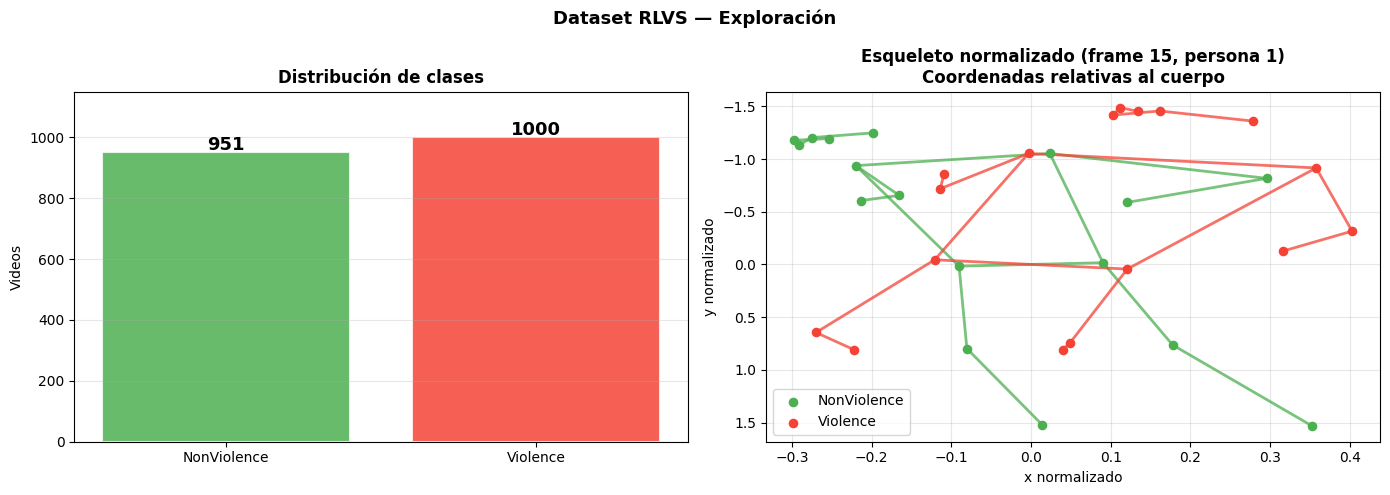

Total   : 1951  videos
  NonViolence : 951
  Violence    : 1000
Shape input por video: (30, 68)  (frames x features)


In [5]:
# Conexiones del esqueleto COCO-17 para dibujar el cuerpo completo
SKELETON_COCO = [
    (0,1),(0,2),(1,3),(2,4),           # cabeza
    (5,6),(5,7),(7,9),(6,8),(8,10),    # brazos
    (5,11),(6,12),(11,12),             # torso
    (11,13),(13,15),(12,14),(14,16),   # piernas
]
COLORS_CLASS = ['#4CAF50', '#F44336']  # verde=no violencia, rojo=violencia

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Distribución de clases ────────────────────────────────────────────────────
counts = Counter(y.tolist())
bars   = axes[0].bar(CLASSES, [counts[i] for i in range(N_CLASSES)],
                     color=COLORS_CLASS, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, [counts[i] for i in range(N_CLASSES)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(cnt), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Distribución de clases', fontweight='bold')
axes[0].set_ylabel('Videos')
axes[0].set_ylim(0, max(counts.values()) * 1.15)
axes[0].grid(alpha=0.3, axis='y')

# ── Esqueleto normalizado — un ejemplo por clase ──────────────────────────────
for cls_idx in range(N_CLASSES):
    sample_idx = np.where(y == cls_idx)[0][0]
    frame_kp   = X[sample_idx, 15, :N_KP*2].reshape(N_KP, 2)   # frame 15, persona 1
    color      = COLORS_CLASS[cls_idx]

    for (a, b) in SKELETON_COCO:
        if np.any(frame_kp[a] != 0) and np.any(frame_kp[b] != 0):
            axes[1].plot([frame_kp[a,0], frame_kp[b,0]],
                         [frame_kp[a,1], frame_kp[b,1]],
                         color=color, alpha=0.75, linewidth=2)

    valid = np.any(frame_kp != 0, axis=1)
    axes[1].scatter(frame_kp[valid, 0], frame_kp[valid, 1],
                    color=color, s=35, zorder=5, label=CLASSES[cls_idx])

axes[1].set_title('Esqueleto normalizado (frame 15, persona 1)\nCoordenadas relativas al cuerpo',
                  fontweight='bold')
axes[1].set_xlabel('x normalizado'); axes[1].set_ylabel('y normalizado')
axes[1].invert_yaxis()   # eje Y invertido = coordenada de imagen (0 arriba)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Dataset RLVS — Exploración', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/nb4_dataset_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total   : {len(y)}  videos')
for i, name in enumerate(CLASSES):
    print(f'  {name:12s}: {(y==i).sum()}')
print(f'Shape input por video: {X.shape[1:]}  (frames x features)')

## 3. Dataset y DataLoader

**División 80/20:** 1600 videos para entrenar, 400 para validar.
Usamos una semilla fija (`SEED=42`) para que el split sea reproducible entre ejecuciones.

**WeightedRandomSampler:**
Aunque RLVS está perfectamente balanceado (1000/1000), el sampler garantiza que cada batch
contenga aproximadamente el mismo número de ambas clases. Si en el futuro se añaden más videos
de una clase, el sampler lo compensa automáticamente sin cambiar nada más.


In [6]:
class FightDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Split 80/20 con permutación aleatoria fija
n       = len(y)
indices = np.random.default_rng(SEED).permutation(n)
n_val   = int(n * 0.20)
train_idx, val_idx = indices[n_val:], indices[:n_val]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]

# WeightedRandomSampler: cada clase tiene igual probabilidad de aparecer en el batch
counts_train = Counter(y_train.tolist())
weights      = [1.0 / counts_train[int(lbl)] for lbl in y_train]
sampler      = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_ds = FightDataset(X_train, y_train)
val_ds   = FightDataset(X_val,   y_val)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)

print(f'Train  : {len(train_ds)} videos  |  {len(train_dl)} batches')
print(f'Val    : {len(val_ds)} videos  |  {len(val_dl)} batches')
for split, y_s in [('Train', y_train), ('Val', y_val)]:
    c = Counter(y_s.tolist())
    print(f'  {split}: NonViolence={c[0]}  Violence={c[1]}')

Train  : 1561 videos  |  49 batches
Val    : 390 videos  |  13 batches
  Train: NonViolence=763  Violence=798
  Val: NonViolence=188  Violence=202


## 4. Arquitectura — FightLSTM

```
Input  (batch, 30, 68)
  ↓
Input Projection   Linear(68→128) + ReLU + Dropout(0.4)
  ↓
BiLSTM             hidden=256, layers=2, bidirectional=True
                   salida: 512 features  (256 forward + 256 backward)
  ↓
Clasificador       Linear(512→128) → ReLU → Dropout → Linear(128→64) → ReLU → Linear(64→2)
  ↓
Output  logits  [NonViolence, Violence]
```

**Por qué Input Projection:**
Los 68 keypoints crudos son coordenadas numéricas simples. Proyectarlos a 128 dimensiones
le da a la red una primera capa para aprender qué combinaciones de puntos son relevantes
(por ejemplo: distancia entre muñecas, apertura de brazos) antes de procesar la secuencia temporal.

**Por qué BiLSTM y no LSTM simple:**
Un LSTM unidireccional solo ve el pasado → solo aprende "qué precede a un golpe".
El pass backward aprende "qué sigue después de un golpe" (persona cayendo, retrocediendo).
Combinar forward + backward da una comprensión completa del evento de ambos extremos.

**Por qué 2 capas de LSTM:**
La primera capa aprende patrones de bajo nivel (movimiento de brazo, cambio de postura).
La segunda capa combina esos patrones en comportamientos más abstractos (secuencia de ataque).


In [7]:
class FightLSTM(nn.Module):
    """
    Clasificador de peleas basado en secuencias de keypoints corporales.

    Input : (batch, N_FRAMES=30, FEATURES=68)
            FEATURES = 2 personas x 17 keypoints COCO x 2 coords (x, y)
    Output: dict con 'logits' y 'probs'  shape (batch, 2)
    """

    def __init__(self):
        super().__init__()

        # Proyección inicial: transforma los 68 keypoints crudos a 128 dimensiones
        self.input_proj = nn.Sequential(
            nn.Linear(FEATURES, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
        )

        # BiLSTM: procesa la secuencia en ambas direcciones
        # dropout solo entre capas intermedias (no en la ultima)
        self.lstm = nn.LSTM(
            input_size    = 128,
            hidden_size   = HIDDEN_SIZE,
            num_layers    = NUM_LAYERS,
            batch_first   = True,
            dropout       = DROPOUT if NUM_LAYERS > 1 else 0.0,
            bidirectional = True,
        )

        # Clasificador final
        # HIDDEN_SIZE*2 porque bidireccional: 256 forward + 256 backward = 512
        self.classifier = nn.Sequential(
            nn.Linear(HIDDEN_SIZE * 2, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, N_CLASSES),
        )

    def forward(self, x):
        B, T, _ = x.shape

        # Proyectar cada frame independientemente (mismos pesos para todos los frames)
        proj = self.input_proj(x.view(B * T, -1)).view(B, T, 128)

        # Pasar secuencia por BiLSTM — out: (batch, 30, 512)
        out, _ = self.lstm(proj)

        # Tomar el ultimo timestep: acumula toda la informacion de la secuencia
        last   = out[:, -1, :]      # (batch, 512)
        logits = self.classifier(last)

        return {'logits': logits, 'probs': F.softmax(logits, dim=-1)}


model     = FightLSTM().to(DEVICE)
total_p   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'FightLSTM — parametros entrenables: {total_p:,}')
print(f'  Input projection : {sum(p.numel() for p in model.input_proj.parameters()):,}')
print(f'  BiLSTM           : {sum(p.numel() for p in model.lstm.parameters()):,}')
print(f'  Clasificador     : {sum(p.numel() for p in model.classifier.parameters()):,}')
print(f'  Device           : {DEVICE}')

FightLSTM — parametros entrenables: 2,450,370
  Input projection : 8,832
  BiLSTM           : 2,367,488
  Clasificador     : 74,050
  Device           : cuda


## 5. Entrenamiento

**AdamW:** Variante de Adam con regularización L2 correctamente desacoplada del gradiente.
Más estable que Adam estándar para modelos con dropout y recurrentes.

**CosineAnnealingLR:** Reduce el learning rate siguiendo una curva coseno de `LR` hasta `1e-5`.
Evita oscillaciones al final del entrenamiento y suele converger a mejores mínimos que
un LR fijo o stepwise decay.

**Gradient Clipping (`max_norm=1.0`):**
Los LSTMs pueden sufrir gradientes explosivos cuando las secuencias son largas.
Clipping limita la norma del gradiente a 1.0, estabilizando el entrenamiento sin
necesidad de bajar el learning rate prematuramente.


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[]}
best_val_acc = 0.0

print(f'Entrenando {EPOCHS} epocas  |  batch={BATCH_SIZE}  |  lr={LR}  |  device={DEVICE}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_corr, t_n = 0.0, 0, 0

    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out['logits'], y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item() * len(y_batch)
        t_corr += (out['logits'].argmax(-1) == y_batch).sum().item()
        t_n    += len(y_batch)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_corr, v_n = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_dl:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            out  = model(X_batch)
            loss = criterion(out['logits'], y_batch)
            v_loss += loss.item() * len(y_batch)
            v_corr += (out['logits'].argmax(-1) == y_batch).sum().item()
            v_n    += len(y_batch)

    scheduler.step()
    tl = t_loss/t_n; ta = t_corr/t_n
    vl = v_loss/v_n; va = v_corr/v_n

    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    history['lr'].append(scheduler.get_last_lr()[0])

    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), SAVE_PATH)
        marker = ' *'
    else:
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Ep {epoch:3d}/{EPOCHS}  '
              f'loss {tl:.4f}/{vl:.4f}  '
              f'acc {ta*100:.1f}%/{va*100:.1f}%'
              f'{marker}')

print(f'\nMejor val accuracy : {best_val_acc*100:.2f}%')
print(f'Modelo guardado en : {SAVE_PATH}')

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print('Mejor modelo cargado para evaluacion')

Entrenando 40 epocas  |  batch=32  |  lr=0.001  |  device=cuda
-----------------------------------------------------------------
Ep   1/40  loss 0.5832/0.5533  acc 71.6%/74.6% *
Ep   5/40  loss 0.4188/0.4431  acc 82.1%/79.2%
Ep  10/40  loss 0.3081/0.5912  acc 88.0%/80.3%
Ep  15/40  loss 0.2843/0.4643  acc 89.3%/83.6% *
Ep  20/40  loss 0.2184/0.4710  acc 92.4%/83.8%
Ep  25/40  loss 0.1904/0.4773  acc 93.2%/84.9%
Ep  30/40  loss 0.1436/0.5366  acc 94.9%/85.1%
Ep  35/40  loss 0.1206/0.5403  acc 96.1%/85.4%
Ep  40/40  loss 0.1071/0.5820  acc 96.5%/85.6%

Mejor val accuracy : 86.15%
Modelo guardado en : models/fight_detector.pth
Mejor modelo cargado para evaluacion


## 6. Visualizaciones de Entrenamiento y Evaluación

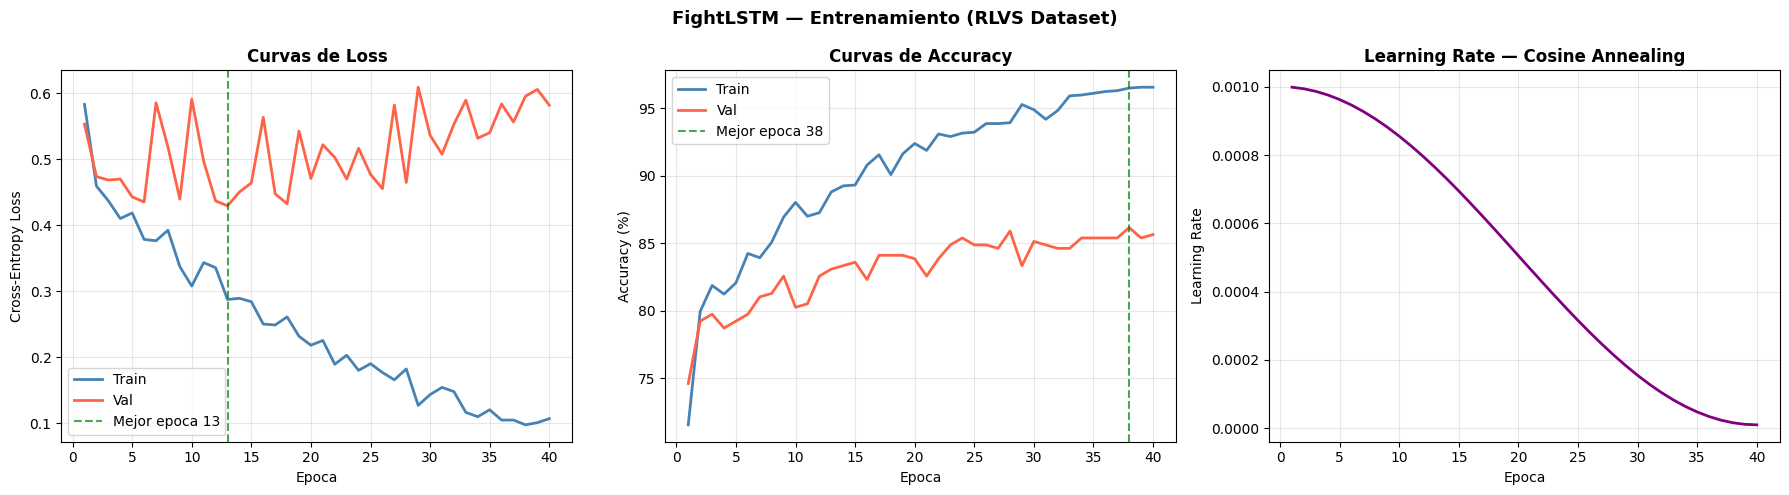

Train loss final   : 0.1071
Val   loss final   : 0.5820
Mejor val accuracy : 86.15%  (epoca 38)


In [9]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes    = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='tomato',    lw=2)
best_ep = int(np.argmin(history['val_loss'])) + 1
axes[0].axvline(best_ep, color='green', ls='--', alpha=0.7, label=f'Mejor epoca {best_ep}')
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Curvas de Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [x*100 for x in history['train_acc']], label='Train', color='steelblue', lw=2)
axes[1].plot(epochs_range, [x*100 for x in history['val_acc']],   label='Val',   color='tomato',    lw=2)
best_ep_acc = int(np.argmax(history['val_acc'])) + 1
axes[1].axvline(best_ep_acc, color='green', ls='--', alpha=0.7, label=f'Mejor epoca {best_ep_acc}')
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Curvas de Accuracy', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning rate
axes[2].plot(epochs_range, history['lr'], color='purple', lw=2)
axes[2].set_xlabel('Epoca'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate — Cosine Annealing', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle('FightLSTM — Entrenamiento (RLVS Dataset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/nb4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Train loss final   : {history["train_loss"][-1]:.4f}')
print(f'Val   loss final   : {history["val_loss"][-1]:.4f}')
print(f'Mejor val accuracy : {max(history["val_acc"])*100:.2f}%  (epoca {best_ep_acc})')

Accuracy en validacion: 86.15%
  NonViolence   n= 188  acc=83.0%
  Violence      n= 202  acc=89.1%


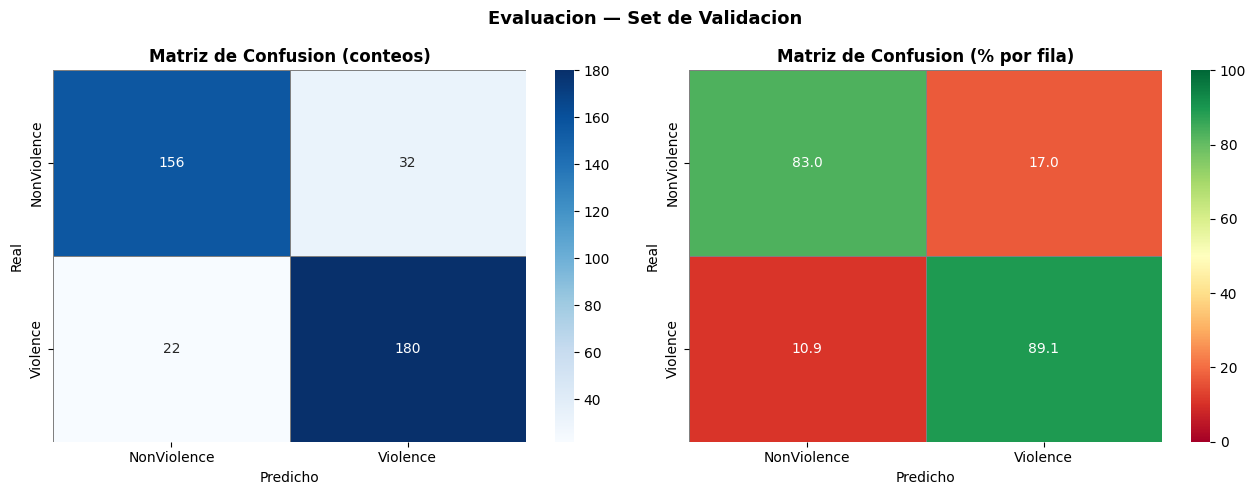

In [10]:
# Recolectar predicciones sobre el set de validación completo
all_preds, all_labels, all_probs = [], [], []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in val_dl:
        out   = model(X_batch.to(DEVICE))
        probs = out['probs'].cpu().numpy()
        preds = out['probs'].argmax(-1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(y_batch.numpy().tolist())
        all_probs.extend(probs.tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

overall_acc = (all_preds == all_labels).mean()
print(f'Accuracy en validacion: {overall_acc*100:.2f}%')
for i, name in enumerate(CLASSES):
    mask = all_labels == i
    acc  = (all_preds[mask] == i).mean() if mask.sum() > 0 else 0.0
    print(f'  {name:12s}  n={mask.sum():4d}  acc={acc*100:.1f}%')

# ── Confusion Matrix ──────────────────────────────────────────────────────────
if HAS_SKLEARN:
    cm     = confusion_matrix(all_labels, all_preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='gray')
    axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
    axes[0].set_title('Matriz de Confusion (conteos)', fontweight='bold')

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
    axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
    axes[1].set_title('Matriz de Confusion (% por fila)', fontweight='bold')

    plt.suptitle('Evaluacion — Set de Validacion', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('output/nb4_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

              precision    recall  f1-score   support

 NonViolence       0.88      0.83      0.85       188
    Violence       0.85      0.89      0.87       202

    accuracy                           0.86       390
   macro avg       0.86      0.86      0.86       390
weighted avg       0.86      0.86      0.86       390



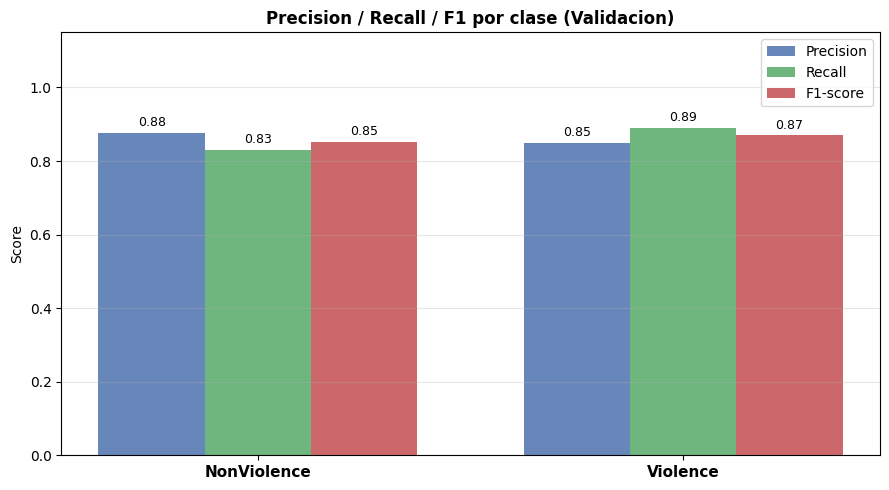

Macro F1   : 86.10%
Accuracy   : 86.15%


In [11]:
if HAS_SKLEARN:
    report = classification_report(all_labels, all_preds,
                                   target_names=CLASSES, output_dict=True)
    print(classification_report(all_labels, all_preds, target_names=CLASSES))

    metrics_names = ['precision', 'recall', 'f1-score']
    x      = np.arange(len(CLASSES))
    width  = 0.25
    colors_bar = ['#4C72B0', '#55A868', '#C44E52']

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, metric in enumerate(metrics_names):
        vals = [report[cls][metric] for cls in CLASSES]
        bars = ax.bar(x + i*width, vals, width, label=metric.capitalize(),
                      color=colors_bar[i], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASSES, fontweight='bold', fontsize=11)
    ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
    ax.set_title('Precision / Recall / F1 por clase (Validacion)', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('output/nb4_per_class_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Macro F1   : {report["macro avg"]["f1-score"]*100:.2f}%')
    print(f'Accuracy   : {overall_acc*100:.2f}%')

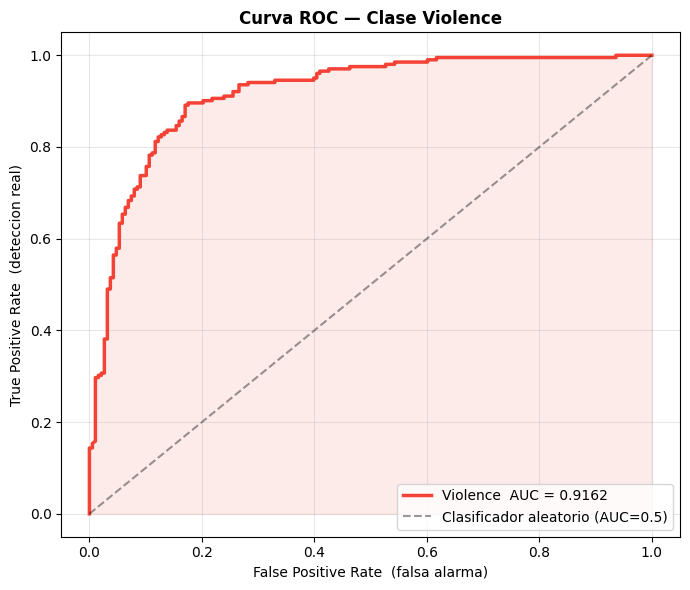

AUC Violence : 0.9162
1.0 = clasificador perfecto | 0.5 = aleatorio


In [12]:
if HAS_SKLEARN:
    # ROC para la clase Violence (probabilidad de Violence = columna 1)
    fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
    roc_auc     = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='#F44336', lw=2.5, label=f'Violence  AUC = {roc_auc:.4f}')
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Clasificador aleatorio (AUC=0.5)')
    ax.fill_between(fpr, tpr, alpha=0.10, color='#F44336')
    ax.set_xlabel('False Positive Rate  (falsa alarma)')
    ax.set_ylabel('True Positive Rate  (deteccion real)')
    ax.set_title('Curva ROC — Clase Violence', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('output/nb4_roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'AUC Violence : {roc_auc:.4f}')
    print('1.0 = clasificador perfecto | 0.5 = aleatorio')

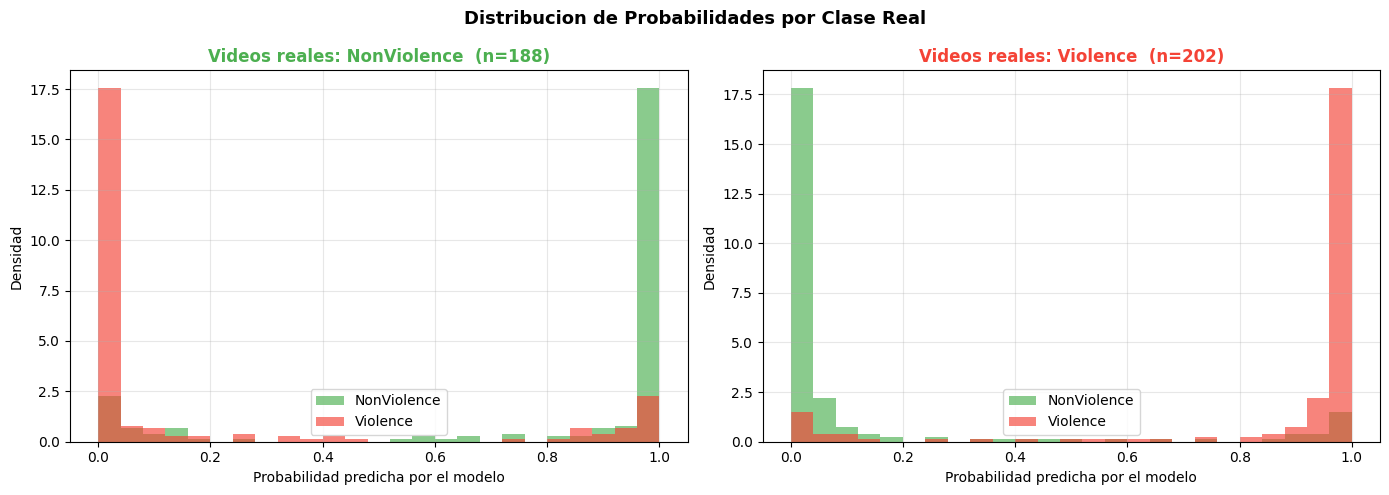

Probabilidad media predicha:
  True NonViolence : NonViolence=0.809  Violence=0.191
  True Violence    : NonViolence=0.128  Violence=0.872


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_cls = ['#4CAF50', '#F44336']

for true_cls in range(N_CLASSES):
    mask      = all_labels == true_cls
    cls_probs = all_probs[mask]
    ax        = axes[true_cls]

    for pred_cls in range(N_CLASSES):
        ax.hist(cls_probs[:, pred_cls], bins=25, alpha=0.65,
                color=colors_cls[pred_cls], label=CLASSES[pred_cls], density=True)

    ax.set_title(f'Videos reales: {CLASSES[true_cls]}  (n={mask.sum()})',
                 fontweight='bold', color=colors_cls[true_cls])
    ax.set_xlabel('Probabilidad predicha por el modelo')
    ax.set_ylabel('Densidad')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Distribucion de Probabilidades por Clase Real', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/nb4_prob_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Probabilidad media predicha:')
for true_cls in range(N_CLASSES):
    mask  = all_labels == true_cls
    means = all_probs[mask].mean(axis=0)
    print(f'  True {CLASSES[true_cls]:12s}: ' +
          '  '.join(f'{CLASSES[i]}={means[i]:.3f}' for i in range(N_CLASSES)))

## Conclusiones

### Dataset
| Fuente | Videos | Clases | Origen real |
|--------|--------|--------|-------------|
| Real Life Violence Situations | 2000 | Violence / NonViolence | YouTube + vigilancia |
| **Paper** | Soliman et al. ICICIS'19 | — | Conferencia internacional |

### Arquitectura FightLSTM
| Componente | Detalle |
|------------|---------|
| Input Projection | Linear(68→128) + ReLU + Dropout — aprende combinaciones relevantes de keypoints |
| BiLSTM | hidden=256, 2 capas, bidireccional — captura dinámica temporal en ambas direcciones |
| Clasificador | 512→128→64→2 — decisión final sobre la secuencia completa |

### Pipeline de producción
```
Cámara en vivo
  → frame  →  YOLOv8n-pose (CUDA)  →  keypoints normalizados
  → buffer 30 frames  →  FightLSTM
  → FIGHT / NO_FIGHT  +  probabilidad  →  alerta en LUCY
```

### Integración en el proyecto
El modelo entrenado (`models/fight_detector.pth`) se carga en `engines/deep_security_engine.py`,
completando el **Módulo 1 — Seguridad Ciudadana** de LUCY junto con el detector de armas.
